<a href="https://colab.research.google.com/github/kachytronico/big-data-hadoop-spark-labs/blob/main/big_data_hadoop_spark_labs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# openpowerlifting_big_data_exam_lab.ipynb


> Alfredo Ledesma Ruiz



## Supuesto  


## Ejercicio 1

1. Copiar los archivos /content/meets.csv y /content/openpowerlifting.csv dentro de /ALF
2. Usa pandas y crea un df por cada archivo df_meet y df_openpl y muestra: Los tipos de datos de cada columna, las primeras 5 filas de los dos df, el número de valores únicos de cada columna y el número de valores faltantes de cada columna.
3. Crea un diagrama de cajas con los calores de : Age, BodyweightKg, BestSquatkg, bestBenchKg. ToalKg y Wilks de openpowerlifting. Pon en el eje x estos nombres: edad peso sentadilla banca Peso muerto Total Wilks. El título tiene que poner "Diagramas de caja del conjunto de datos openpowerlifting"
4. Agreación de datos. Usa la agregación de Pandas para conocer el número de participantes por sexo, división y peso de referencia de cada competición. Relación entro los dos archivos  openpowerlifting.csv.MeetID -> meets.csv.MeetID

## Ejercicio 2

1.  Instalar hadoop, Pig y spark. Configurar y comprobar.
2. Importa los dos archivos csv al sistema de archivos de HDFS en el directorio "examenALF", y comprueba y muestra que se ha hecho correctamente
3. Utiliza GREP de MapReduce para contar las veces que aparece "Tim Smith" en el archivo openpowerlifling.csv
4. Escribe un programa MapReduce en Java que cuente cuántas veces aparece cada palabra en cada uno de los ficheros. Pon especial cuidado en que solo aparezcan palabras, no deben aparecer números.
5. Escribe un programa en MapReduce en Python que cuentre cuantas veces aparece cada palabra en cada uno de los ficheros. Pon especial cuidado en que solo aparezcan palabras, no deben aparecer números.

## Ejercicio 3

1. PIG. En el archivo meet:

  * En las columnas MeetState y MeetTown sustituye los calores nulos por “-“
  * El formato de la columna “date” es “yyyy-mm-dd”, modifícalo para que tenga el formato “dd/mm/yyyy”
  * Comprueba y muestra que se ha hecho correctamente.

2. PIG. Encontrar las 3 palabras más repetidas en ambos archivos.


3. Spark. Importa tus ficheros a una base de datos relacional Hive, muestra los “select *” de las dos tablas creadas.

4. Hive. Mostras cuántas competiciones han tenido participantes de la División "Open Senior".

5. Hive. Obtener, para cada competición, la edad del participante más jovén y más mayor.


# Ejerccio 1



## 1.1 Cargar dataset
Cargo los dataset a mano y miro que contienen para luego en el siguiente paso, meterlos dentro de una carpeta con mis iniciales.

In [ ]:
import pandas as pd
import os

# 1. Comprobar DataFrames ya cargados
dfs_cargados = [var for var in dir() if isinstance(eval(var), pd.DataFrame) and not var.startswith('_')]
print(f"DataFrames ya cargados en memoria: {dfs_cargados}\n")

# 2. Buscar archivos CSV en la ruta principal
archivos_csv = []
for root, dirs, files in os.walk('/content'):
    # Excluimos directorios internos de Colab para evitar ruido
    if '.config' in root or 'sample_data' in root or 'BDA_examen' in root:
        continue
    for f in files:
        if f.endswith('.csv'):
            archivos_csv.append(os.path.join(root, f))

print(f"Archivos CSV encontrados: {archivos_csv}\n")
print("="*60)

# 3. Cargar y explorar cada dataset encontrado
for archivo in archivos_csv:
    nombre_df = "df_" + os.path.splitext(os.path.basename(archivo))[0]

    if nombre_df not in dfs_cargados:
        try:
            print(f"\n\n🔍 EXPLORANDO: {archivo}")
            df = pd.read_csv(archivo)
            globals()[nombre_df] = df  # Guardar en memoria global

            print(f"Shape: {df.shape}")
            print(f"Filas duplicadas: {df.duplicated().sum()}")
            print("\n--- INFO ---")
            df.info()

            print("\n--- INVENTARIO POR COLUMNA ---")
            inventario = []
            for col in df.columns:
                ejemplos = df[col].dropna().unique()[:3].tolist()
                inventario.append({
                    'Columna': col,
                    'Dtype': str(df[col].dtype),
                    'Únicos': df[col].nunique(),
                    'Nulos': df[col].isnull().sum(),
                    'Ejemplos': ejemplos
                })
            display(pd.DataFrame(inventario))

            print("\n--- HEAD ---")
            display(df.head(3))
            print("\n" + "="*60)
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")

DataFrames ya cargados en memoria: []

Archivos CSV encontrados: ['/content/openpowerlifting.csv', '/content/meets.csv']



🔍 EXPLORANDO: /content/openpowerlifting.csv
Shape: (224434, 17)
Filas duplicadas: 393

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224434 entries, 0 to 224433
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   MeetID          224434 non-null  int64  
 1   Name            224434 non-null  object 
 2   Sex             224434 non-null  object 
 3   Equipment       224434 non-null  object 
 4   Age             44558 non-null   float64
 5   Division        210336 non-null  object 
 6   BodyweightKg    222886 non-null  float64
 7   WeightClassKg   222333 non-null  object 
 8   Squat4Kg        684 non-null     float64
 9   BestSquatKg     172218 non-null  float64
 10  Bench4Kg        1182 non-null    float64
 11  BestBenchKg     208893 non-null  float64
 12  Deadlift4Kg     

,Columna,Dtype,Únicos,Nulos,Ejemplos
0,MeetID,int64,6305,0,"[0, 1, 2]"
1,Name,object,83090,0,"[Angie Belk Terry, Dawn Bogart, Destiny Dula]"
2,Sex,object,2,0,"[F, M]"
3,Equipment,object,5,0,"[Wraps, Single-ply, Raw]"
4,Age,float64,158,179876,"[47.0, 42.0, 18.0]"
5,Division,object,2954,14098,"[Mst 45-49, Mst 40-44, Open Senior]"
6,BodyweightKg,float64,8121,1548,"[59.6, 58.51, 63.68]"
7,WeightClassKg,object,49,2101,"[60, 67.5, 75]"
8,Squat4Kg,float64,336,223750,"[-183.7, 367.41, 195.04]"
9,BestSquatKg,float64,998,52216,"[47.63, 142.88, 170.1]"



--- HEAD ---


,MeetID,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38





🔍 EXPLORANDO: /content/meets.csv
Shape: (8482, 8)
Filas duplicadas: 0

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8482 entries, 0 to 8481
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   MeetID       8482 non-null   int64 
 1   MeetPath     8482 non-null   object
 2   Federation   8482 non-null   object
 3   Date         8482 non-null   object
 4   MeetCountry  8482 non-null   object
 5   MeetState    5496 non-null   object
 6   MeetTown     6973 non-null   object
 7   MeetName     8482 non-null   object
dtypes: int64(1), object(7)
memory usage: 530.3+ KB

--- INVENTARIO POR COLUMNA ---


,Columna,Dtype,Únicos,Nulos,Ejemplos
0,MeetID,int64,8482,0,"[0, 1, 2]"
1,MeetPath,object,8482,0,"[365strong/1601, 365strong/1602, 365strong/1603]"
2,Federation,object,60,0,"[365Strong, AAU, ADFPA]"
3,Date,object,2652,0,"[2016-10-29, 2016-11-19, 2016-07-09]"
4,MeetCountry,object,45,0,"[USA, Australia, Finland]"
5,MeetState,object,80,2986,"[NC, MO, SC]"
6,MeetTown,object,1539,1509,"[Charlotte, Ozark, Rock Hill]"
7,MeetName,object,5217,0,[2016 Junior & Senior National Powerlifting Ch...



--- HEAD ---


,MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,0,365strong/1601,365Strong,2016-10-29,USA,NC,Charlotte,2016 Junior & Senior National Powerlifting Cha...
1,1,365strong/1602,365Strong,2016-11-19,USA,MO,Ozark,Thanksgiving Powerlifting Classic
2,2,365strong/1603,365Strong,2016-07-09,USA,NC,Charlotte,Charlotte Europa Games


## 1.2 Mover archivos a /ALF

Según el enunciado, debemos crear la carpeta `/ALF` en la raíz y mover los datasets principales allí.


### CUIDADO

> Al moverlo había perdido filas y he copiado los archivos en vez de moverlos y funciona



In [ ]:
!rm -rf /ALF
!mkdir -p /ALF
!cp /content/meets.csv /ALF/ 2>/dev/null || true
!cp /content/openpowerlifting.csv /ALF/ 2>/dev/null || true

print("Contenido de /ALF:")
!ls -lh /ALF

Contenido de /ALF:
total 19M
-rw-r--r-- 1 root root 609K Apr 29 17:12 meets.csv
-rw-r--r-- 1 root root  18M Apr 29 17:12 openpowerlifting.csv


## 1.2. Carga y perfilado básico con Pandas

Creamos los DataFrames `df_meet` y `df_openpl` leyendo desde `/ALF`, y mostramos para cada uno:

- Tipos de datos por columna.
- Las primeras 5 filas.
- Número de valores únicos por columna.
- Número de valores faltantes por columna.

In [ ]:
import pandas as pd

# Cargar los archivos desde el directorio /ALF
df_meet = pd.read_csv('/ALF/meets.csv')
df_openpl = pd.read_csv('/ALF/openpowerlifting.csv')

dataframes = {'df_meet': df_meet, 'df_openpl': df_openpl}

# 1. Tipos de datos por columna
print("\n" + "="*60)
print("--- TIPOS DE DATOS POR COLUMNA ---")
print("="*60)
for nombre, df in dataframes.items():
    print(f"\n[{nombre.upper()}]")
    display(df.dtypes.to_frame(name='Tipo de Dato'))

# 2. Primeras 5 filas
print("\n" + "="*60)
print("--- PRIMERAS 5 FILAS ---")
print("="*60)
for nombre, df in dataframes.items():
    print(f"\n[{nombre.upper()}]")
    display(df.head(5))

# 3. Valores únicos
print("\n" + "="*60)
print("--- VALORES ÚNICOS POR COLUMNA ---")
print("="*60)
for nombre, df in dataframes.items():
    print(f"\n[{nombre.upper()}]")
    display(df.nunique().to_frame(name='Valores Únicos'))

# 4. Valores faltantes
print("\n" + "="*60)
print("--- VALORES FALTANTES POR COLUMNA ---")
print("="*60)
for nombre, df in dataframes.items():
    print(f"\n[{nombre.upper()}]")
    display(df.isnull().sum().to_frame(name='Valores Faltantes'))



--- TIPOS DE DATOS POR COLUMNA ---

[DF_MEET]


,Tipo de Dato
MeetID,int64
MeetPath,object
Federation,object
Date,object
MeetCountry,object
MeetState,object
MeetTown,object
MeetName,object



[DF_OPENPL]


,Tipo de Dato
MeetID,int64
Name,object
Sex,object
Equipment,object
Age,float64
Division,object
BodyweightKg,float64
WeightClassKg,object
Squat4Kg,float64
BestSquatKg,float64



--- PRIMERAS 5 FILAS ---

[DF_MEET]


...

,Valores Únicos
MeetID,6473
Name,85255
Sex,2
Equipment,5
Age,158
Division,3222
BodyweightKg,8204
WeightClassKg,49
Squat4Kg,343
BestSquatKg,1013



--- VALORES FALTANTES POR COLUMNA ---

[DF_MEET]


,Valores Faltantes
MeetID,0
MeetPath,0
Federation,0
Date,0
MeetCountry,0
MeetState,2986
MeetTown,1509
MeetName,0



[DF_OPENPL]


,Valores Faltantes
MeetID,0
Name,0
Sex,0
Equipment,0
Age,190327
Division,14098
BodyweightKg,1813
WeightClassKg,2348
Squat4Kg,236671
BestSquatKg,53875


## 1.3. Diagramas de caja de openpowerlifting

Creamos un diagrama de cajas con las variables clave del dataset de openpowerlifting para visualizar su distribución y valores atípicos, asignando las etiquetas solicitadas en el eje X.

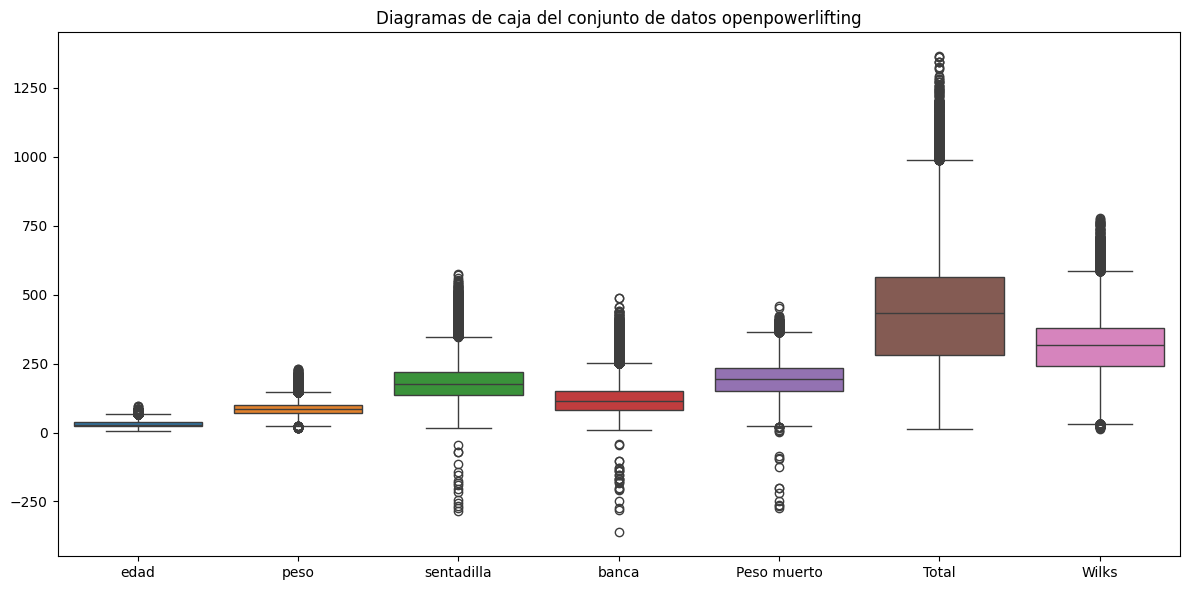

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definir las columnas a visualizar y sus etiquetas correspondientes
# (Se incluye BestDeadliftKg para corresponder con la etiqueta 'Peso muerto')
columnas = ['Age', 'BodyweightKg', 'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg', 'Wilks']
etiquetas = ['edad', 'peso', 'sentadilla', 'banca', 'Peso muerto', 'Total', 'Wilks']

# Crear el gráfico
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_openpl[columnas])

# Añadir título y etiquetas al eje X
plt.title('Diagramas de caja del conjunto de datos openpowerlifting')
plt.xticks(ticks=range(len(etiquetas)), labels=etiquetas)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

## 1.4. Agreación de datos.

In [ ]:
# Agrupamos por competición, sexo, división y peso de referencia
# y usamos la función de agregación 'count' sobre la columna 'Name'
df_participantes = df_openpl.groupby(['MeetID', 'Sex', 'Division', 'WeightClassKg']).agg(
    Num_Participantes=('Name', 'count')
).reset_index()

# Realizamos el cruce (merge) usando la clave común 'MeetID'
df_merged = pd.merge(df_participantes, df_meet, on='MeetID', how='left')

# Renombramos 'Num_Participantes' a 'Participantes' para que coincida con lo solicitado
df_merged = df_merged.rename(columns={'Num_Participantes': 'Participantes'})

# Seleccionamos y mostramos las columnas específicas pedidas
columnas_mostrar = ['MeetName', 'Sex', 'Division', 'WeightClassKg', 'Participantes']

print("--- Participantes por Competición (Merge con MeetName) ---")
display(df_merged[columnas_mostrar].head(10))

--- Participantes por Competición (Merge con MeetName) ---


,MeetName,Sex,Division,WeightClassKg,Participantes
0,2016 Junior & Senior National Powerlifting Cha...,F,50-54,67.5,1
1,2016 Junior & Senior National Powerlifting Cha...,F,Junior,67.5,1
2,2016 Junior & Senior National Powerlifting Cha...,F,Mst 40-44,60,1
3,2016 Junior & Senior National Powerlifting Cha...,F,Mst 45-49,60,1
4,2016 Junior & Senior National Powerlifting Cha...,F,Mst 50-54,75,1
5,2016 Junior & Senior National Powerlifting Cha...,F,Mst 55-59,75,1
6,2016 Junior & Senior National Powerlifting Cha...,F,Mst 55-59,90,1
7,2016 Junior & Senior National Powerlifting Cha...,F,Mst 60-64,67.5,1
8,2016 Junior & Senior National Powerlifting Cha...,F,Open Junior,90,1
9,2016 Junior & Senior National Powerlifting Cha...,F,Open Junior,90+,1


# Ejercicio 2


## 2.1 Hadoop PIG y SPARK

Lo primero que hago es activar el soporte de GPU.

**"Entorno de ejecución" > "Cambiar tipo de entorno de ejecución"**

### Instalación de Hadoop

In [ ]:
import os

# 1. Verificar Java disponible (Colab trae Java 17 preinstalado)
!ls -l /usr/lib/jvm/

# 2. Descargar Hadoop 3.4.2
!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.4.2/hadoop-3.4.2.tar.gz

# 3. Descomprimir y mover a /usr/local/hadoop
!tar -xzf hadoop-3.4.2.tar.gz
!mv hadoop-3.4.2/ /usr/local/hadoop

# 4. Configurar variables de entorno
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/usr/local/hadoop"
os.environ["PATH"] += f":{os.environ['HADOOP_HOME']}/bin:{os.environ['HADOOP_HOME']}/sbin"

# 5. Verificar instalación
!hadoop version
!ls /usr/local/hadoop

total 4
lrwxrwxrwx 1 root root   21 Jan 29 03:35 java-1.17.0-openjdk-amd64 -> java-17-openjdk-amd64
drwxr-xr-x 9 root root 4096 Mar 30 13:14 java-17-openjdk-amd64
Hadoop 3.4.2
Source code repository https://github.com/apache/hadoop.git -r 84e8b89ee2ebe6923691205b9e171badde7a495c
Compiled by ahmarsu on 2025-08-20T10:30Z
Compiled on platform linux-x86_64
Compiled with protoc 3.23.4
From source with checksum fa94c67d4b4be021b9e9515c9b0f7b6
This command was run using /usr/local/hadoop/share/hadoop/common/hadoop-common-3.4.2.jar
bin  include  libexec	      licenses-binary  NOTICE-binary  README.txt  share
etc  lib      LICENSE-binary  LICENSE.txt      NOTICE.txt     sbin


### Instalación de Pig y configuración de entrono

In [ ]:
%%bash
wget https://downloads.apache.org/pig/pig-0.17.0/pig-0.17.0.tar.gz
tar -xzf pig-0.17.0.tar.gz
cp -r pig-0.17.0/ /usr/local/

--2026-04-29 17:13:44--  https://downloads.apache.org/pig/pig-0.17.0/pig-0.17.0.tar.gz
Resolving downloads.apache.org (downloads.apache.org)... 135.181.214.104, 88.99.208.237, 2a01:4f8:10a:39da::2, ...
Connecting to downloads.apache.org (downloads.apache.org)|135.181.214.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 230606579 (220M) [application/x-gzip]
Saving to: ‘pig-0.17.0.tar.gz’

     0K .......... .......... .......... .......... ..........  0%  129K 29m4s
    50K .......... .......... .......... .......... ..........  0%  259K 21m47s
   100K .......... .......... .......... .......... ..........  0% 20.2M 14m34s
   150K .......... .......... .......... .......... ..........  0% 19.5M 10m59s
   200K .......... .......... .......... .......... ..........  0%  263K 11m38s
   250K .......... .......... .......... .......... ..........  0% 18.7M 9m43s
   300K .......... .......... .......... .......... ..........  0% 20.9M 8m21s
   350K .......... ....

Establecemos las variables de entorno para Pig

In [ ]:
import os
# Update PIG_CLASSPATH
os.environ["PIG_HOME"] = "/usr/local/pig-0.17.0"
os.environ["PATH"] = os.environ["PATH"] + ":" + "/usr/local/pig-0.17.0/bin"
os.environ["PIG_CLASSPATH"] = "/usr/local/hadoop-3.4.2/etc/hadoop"

Verificamos la instalación

In [ ]:
!pig -h -version


Apache Pig version 0.17.0 (r1797386) 
compiled Jun 02 2017, 15:41:58

USAGE: Pig [options] [-] : Run interactively in grunt shell.
       Pig [options] -e[xecute] cmd [cmd ...] : Run cmd(s).
       Pig [options] [-f[ile]] file : Run cmds found in file.
  options include:
    -4, -log4jconf - Log4j configuration file, overrides log conf
    -b, -brief - Brief logging (no timestamps)
    -c, -check - Syntax check
    -d, -debug - Debug level, INFO is default
    -e, -execute - Commands to execute (within quotes)
    -f, -file - Path to the script to execute
    -g, -embedded - ScriptEngine classname or keyword for the ScriptEngine
    -h, -help - Display this message. You can specify topic to get help for that topic.
        properties is the only topic currently supported: -h properties.
    -i, -version - Display version information
    -l, -logfile - Path to client side log file; default is current working directory.
    -m, -param_file - Path to the parameter file
    -p, -param - K

### Ecosistema Hadoop (Pig, Spark, Hive)


### Instalación de Spark

In [ ]:
import os

# 1. Limpiar restos
!rm -rf /content/spark-*
!rm -f /content/spark-*.tgz

# 2. Descubrir qué versión 3.5.x sirve dlcdn AHORA
!curl -s https://dlcdn.apache.org/spark/ | grep -oE 'spark-3\.5\.[0-9]+' | sort -u

spark-3.5.8


In [ ]:
SPARK_VERSION = "3.5.8"   # ← sustituir X por lo que diga el comando anterior

!wget https://dlcdn.apache.org/spark/spark-{SPARK_VERSION}/spark-{SPARK_VERSION}-bin-hadoop3.tgz

size_mb = os.path.getsize(f"/content/spark-{SPARK_VERSION}-bin-hadoop3.tgz") / 1024 / 1024
print(f"\nTamaño: {size_mb:.1f} MB")
assert size_mb > 350, f"Descarga truncada ({size_mb:.1f} MB)."

!tar xf /content/spark-{SPARK_VERSION}-bin-hadoop3.tgz -C /content/

os.environ["JAVA_HOME"]  = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = f"/content/spark-{SPARK_VERSION}-bin-hadoop3"

!pip install -q findspark
import findspark
findspark.init()

# Iniciar sesión de Spark con soporte para Hive
from pyspark.sql import SparkSession
spark = (SparkSession.builder
    .appName("BDA_Examen")
    .config("spark.sql.warehouse.dir", "/content/spark-warehouse")
    .enableHiveSupport()
    .getOrCreate())

print("\n✅ Spark", spark.version)

--2026-04-29 17:14:04--  https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
Resolving dlcdn.apache.org (dlcdn.apache.org)... 151.101.2.132, 2a04:4e42::644
Connecting to dlcdn.apache.org (dlcdn.apache.org)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 401378872 (383M) [application/x-gzip]
Saving to: ‘spark-3.5.8-bin-hadoop3.tgz’

spark-3.5.8-bin-had 100%[===================>] 382.78M   628MB/s    in 0.6s    

2026-04-29 17:14:05 (628 MB/s) - ‘spark-3.5.8-bin-hadoop3.tgz’ saved [401378872/401378872]


Tamaño: 382.8 MB

✅ Spark 3.5.8



## 2.2 Importa los dos archivos csv al sistema de archivos de HDFS en el directorio .

In [ ]:
!ls -lh /ALF

total 19M
-rw-r--r-- 1 root root 609K Apr 29 17:12 meets.csv
-rw-r--r-- 1 root root  18M Apr 29 17:12 openpowerlifting.csv


In [ ]:
import shutil

# 1. Preparamos los archivos localmente en /content/ para mayor comodidad
shutil.copy('/ALF/meets.csv', '/content/meets.csv')
shutil.copy('/ALF/openpowerlifting.csv', '/content/openpowerlifting.csv')
print("Archivos listos en /content/")

# 2. Creamos el directorio en HDFS (el enunciado pide expresamente 'examenALF')
!hdfs dfs -mkdir -p examenALF

# 3. Copiamos los archivos desde el sistema local al HDFS
!hdfs dfs -put -f /content/meets.csv examenALF/
!hdfs dfs -put -f /content/openpowerlifting.csv examenALF/

# 4. Verificamos que se han subido correctamente listando el directorio HDFS
print("\n--- Contenido del directorio HDFS 'examenALF' ---")
!hdfs dfs -ls examenALF/

Archivos listos en /content/

--- Contenido del directorio HDFS 'examenALF' ---
Found 2 items
-rw-r--r--   1 root root     623301 2026-04-29 17:14 examenALF/meets.csv
-rw-r--r--   1 root root   18874368 2026-04-29 17:14 examenALF/openpowerlifting.csv


### CUIDADO

> Al moverlo había perdido filas y he copiado los archivos en vez de moverlos y funciona



In [ ]:
print("--- Comparando tamaños (Bytes) ---")
!stat -c "%s bytes (Local)" /content/openpowerlifting.csv
!hdfs dfs -ls examenALF/openpowerlifting.csv | awk '{print $5, "bytes (HDFS)"}'

print("\n--- Comparando conteo de líneas ---")
!wc -l /content/openpowerlifting.csv | awk '{print $1, "líneas (Local)"}'
!hdfs dfs -cat examenALF/openpowerlifting.csv | wc -l | awk '{print $1, "líneas (HDFS)"}'

print("\n--- Comparando firmas MD5")
!md5sum /content/openpowerlifting.csv
!hdfs dfs -cat examenALF/openpowerlifting.csv 2>/dev/null | md5sum

--- Comparando tamaños (Bytes) ---
18874368 bytes (Local)
18874368 bytes (HDFS)

--- Comparando conteo de líneas ---
237369 líneas (Local)
237369 líneas (HDFS)

--- Comparando firmas MD5
c46c8d243bed27988d7451a0dc731e5f  /content/openpowerlifting.csv
c46c8d243bed27988d7451a0dc731e5f  -


## 2.3 Utiliza GREP de MapReduce para contar las veces que aparece "Tim Smith" en el archivo openpowerlifling.csv

In [ ]:
# 1. Limpieza preventiva del directorio de salida
!hdfs dfs -rm -r grep_tim_smith 2>/dev/null || true

# 2. Ejecutar grep de MapReduce sobre la carpeta examenALF entera
!hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-*.jar \
    grep examenALF grep_tim_smith 'Tim Smith'

# 3. Listar el directorio de salida y mostrar el resultado
print("\n--- Contenido de grep_tim_smith/ ---")
!hdfs dfs -ls grep_tim_smith
print("\n--- Resultado del conteo ---")
!hdfs dfs -cat grep_tim_smith/part-r-00000


2026-04-29 17:14:27,715 INFO input.FileInputFormat: Total input files to process : 2
2026-04-29 17:14:27,733 INFO mapreduce.JobSubmitter: number of splits:2
2026-04-29 17:14:27,961 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local1619908746_0001
2026-04-29 17:14:27,962 INFO mapreduce.JobSubmitter: Executing with tokens: []
2026-04-29 17:14:28,067 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2026-04-29 17:14:28,068 INFO mapreduce.Job: Running job: job_local1619908746_0001
2026-04-29 17:14:28,068 INFO mapred.LocalJobRunner: OutputCommitter set in config null
2026-04-29 17:14:28,073 INFO output.PathOutputCommitterFactory: No output committer factory defined, defaulting to FileOutputCommitterFactory
2026-04-29 17:14:28,074 INFO output.FileOutputCommitter: File Output Committer Algorithm version is 2
2026-04-29 17:14:28,074 INFO output.FileOutputCommitter: FileOutputCommitter skip cleanup _temporary folders under output directory:false, ignore cleanup

Ahora si que aparecen 7

## 2.4. MapReduce en Java: Conteo de palabras (filtrando números)

Adaptamos la plantilla de WordCount para asegurarnos de que solo se tengan en cuenta palabras. En el **Mapper**, limpiaremos los números y signos de puntuación utilizando expresiones regulares.

In [ ]:
%%writefile WordCount.java
import org.apache.hadoop.conf.Configuration;
import org.apache.hadoop.fs.Path;
import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Job;
import org.apache.hadoop.mapreduce.lib.input.FileInputFormat;
import org.apache.hadoop.mapreduce.lib.output.FileOutputFormat;

public class WordCount {
    public static void main(String[] args) throws Exception {
        if (args.length != 2) {
            System.err.println("Uso: WordCount <input path> <output path>");
            System.exit(-1);
        }
        Configuration conf = new Configuration();
        Job job = Job.getInstance(conf, "word count");

        job.setJarByClass(WordCount.class);
        job.setMapperClass(WordCountMapper.class);
        job.setCombinerClass(WordCountReducer.class);
        job.setReducerClass(WordCountReducer.class);

        job.setOutputKeyClass(Text.class);
        job.setOutputValueClass(IntWritable.class);

        FileInputFormat.addInputPath(job, new Path(args[0]));
        FileOutputFormat.setOutputPath(job, new Path(args[1]));

        System.exit(job.waitForCompletion(true) ? 0 : 1);
    }
}

Writing WordCount.java


In [ ]:
%%writefile WordCountMapper.java
import java.io.IOException;
import java.util.StringTokenizer;

import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Mapper;

public class WordCountMapper extends Mapper<Object, Text, Text, IntWritable> {

    private final static IntWritable one = new IntWritable(1);
    private Text word = new Text();

    @Override
    public void map(Object key, Text value, Context context) throws IOException, InterruptedException {
        // Convertimos a minúsculas y reemplazamos todo lo que NO sea letra por espacios.
        // Esto elimina números y signos de puntuación de un plumazo.
        String cleanLine = value.toString().toLowerCase().replaceAll("[^a-záéíóúñü]", " ");

        StringTokenizer itr = new StringTokenizer(cleanLine);

        while (itr.hasMoreTokens()) {
            String token = itr.nextToken().trim();

            // Aseguramos que el token no está vacío y no contiene números por seguridad extra
            if (!token.isEmpty() && !token.matches(".*\\d.*")) {
                word.set(token);
                context.write(word, one);
            }
        }
    }
}

Writing WordCountMapper.java


In [ ]:
%%writefile WordCountReducer.java
import java.io.IOException;

import org.apache.hadoop.io.IntWritable;
import org.apache.hadoop.io.Text;
import org.apache.hadoop.mapreduce.Reducer;

public class WordCountReducer extends Reducer<Text, IntWritable, Text, IntWritable> {

    private IntWritable result = new IntWritable();

    @Override
    public void reduce(Text key, Iterable<IntWritable> values, Context context)
            throws IOException, InterruptedException {
        int sum = 0;
        for (IntWritable val : values) {
            sum += val.get();
        }
        result.set(sum);
        context.write(key, result);
    }
}

Writing WordCountReducer.java


In [ ]:
# 1. Compilar los tres archivos juntos
!mkdir -p /tmp/classes
!javac -classpath `hadoop classpath` -d /tmp/classes WordCount.java WordCountMapper.java WordCountReducer.java

# 2. Empaquetar en un único .jar
!jar -cvf wordcount.jar -C /tmp/classes/ .

# 3. Limpiar carpeta de salida si existe (limpieza preventiva obligatoria en UD2)
!hdfs dfs -rm -r wordcount_java 2>/dev/null || true

# 4. Ejecutar el job apuntando al directorio que creamos en el apartado anterior ('examenALF')
!hadoop jar wordcount.jar WordCount examenALF wordcount_java

# 5. Verificar y mostrar resultado
print("\n--- Contenido de wordcount_java/ ---")
!hdfs dfs -ls wordcount_java
print("\n--- Primeras 20 líneas del resultado (solo palabras) ---")
!hdfs dfs -cat wordcount_java/part-r-00000 | head -n 20

added manifest
adding: WordCount.class(in = 1558) (out= 877)(deflated 43%)
adding: WordCountMapper.class(in = 2001) (out= 929)(deflated 53%)
adding: WordCountReducer.class(in = 1697) (out= 721)(deflated 57%)
2026-04-29 17:14:35,673 WARN mapreduce.JobResourceUploader: Hadoop command-line option parsing not performed. Implement the Tool interface and execute your application with ToolRunner to remedy this.
2026-04-29 17:14:35,741 INFO input.FileInputFormat: Total input files to process : 2
2026-04-29 17:14:35,762 INFO mapreduce.JobSubmitter: number of splits:2
2026-04-29 17:14:35,918 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local553240588_0001
2026-04-29 17:14:35,919 INFO mapreduce.JobSubmitter: Executing with tokens: []
2026-04-29 17:14:36,047 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2026-04-29 17:14:36,048 INFO mapreduce.Job: Running job: job_local553240588_0001
2026-04-29 17:14:36,048 INFO mapred.LocalJobRunner: OutputCommitter set in con

*Conclusión*: hecho salen solo palabras

## 2.5. MapReduce en Python (Hadoop Streaming): Conteo de palabras sin números

Replicamos la misma lógica del ejercicio anterior, pero esta vez utilizando Python. Adaptamos el archivo `mapper.py` utilizando expresiones regulares para limpiar la puntuación y descartar cualquier número, asegurándonos de que solo se procesan palabras.

In [ ]:
%%writefile mapper.py
#!/usr/bin/env python3
import sys
import re

for line in sys.stdin:
    # Convertir a minúsculas
    line = line.lower()

    # Reemplazar todo lo que no sea letra (a-z) o caracteres acentuados por espacios
    clean_line = re.sub(r'[^a-záéíóúñü]', ' ', line)

    # Dividir por espacios
    words = clean_line.split()

    for word in words:
        word = word.strip()
        # Por seguridad extra, verificamos que no contenga dígitos y no esté vacío
        if word and not re.search(r'\d', word):
            # Emitir la tupla (palabra, 1)
            print(f"{word}\t1")

Writing mapper.py


In [ ]:
%%writefile reducer.py
#!/usr/bin/env python3
import sys

current_word = None
current_count = 0

for line in sys.stdin:
    line = line.strip()

    # Ignorar líneas mal formadas
    try:
        word, count = line.split("\t", 1)
        count = int(count)
    except ValueError:
        continue

    # Si la palabra es igual a la actual, sumamos
    if current_word == word:
        current_count += count
    else:
        # Si cambia la palabra, emitimos el resultado acumulado de la anterior
        if current_word is not None:
            print(f"{current_word}\t{current_count}")

        # Reiniciamos los contadores para la nueva palabra
        current_word = word
        current_count = count

# Imprimir la última palabra procesada
if current_word is not None:
    print(f"{current_word}\t{current_count}")

Writing reducer.py


In [ ]:
# Limpieza preventiva del directorio de salida
!hdfs dfs -rm -r wordcount_streaming 2>/dev/null || true

# Ejecutar Hadoop Streaming sobre el directorio examenALF entero
!hadoop jar $HADOOP_HOME/share/hadoop/tools/lib/hadoop-streaming-*.jar \
   -files mapper.py,reducer.py \
   -mapper "python3 mapper.py" \
   -reducer "python3 reducer.py" \
   -input examenALF \
   -output wordcount_streaming

# Verificar y mostrar resultado
print("\n--- Contenido de wordcount_streaming/ ---")
!hdfs dfs -ls wordcount_streaming
print("\n--- Primeras 20 líneas del resultado (solo palabras) ---")
!hdfs dfs -cat wordcount_streaming/part-00000 | head -n 20

2026-04-29 17:14:43,860 WARN impl.MetricsSystemImpl: JobTracker metrics system already initialized!
2026-04-29 17:14:44,001 INFO mapred.FileInputFormat: Total input files to process : 2
2026-04-29 17:14:44,014 INFO mapreduce.JobSubmitter: number of splits:2
2026-04-29 17:14:44,178 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local1771745690_0001
2026-04-29 17:14:44,179 INFO mapreduce.JobSubmitter: Executing with tokens: []
2026-04-29 17:14:44,350 INFO mapred.LocalDistributedCacheManager: Localized file:/content/mapper.py as file:/tmp/hadoop-root/mapred/local/job_local1771745690_0001_073947f6-75ae-4895-8f71-fdfede0af8b2/mapper.py
2026-04-29 17:14:44,364 INFO mapred.LocalDistributedCacheManager: Localized file:/content/reducer.py as file:/tmp/hadoop-root/mapred/local/job_local1771745690_0001_15254072-1805-459d-82f0-1d76eb05c672/reducer.py
2026-04-29 17:14:44,412 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2026-04-29 17:14:44,413 INFO mapred.LocalJo

# Ejercicio 3 PIG

## 3.1 PIG en meets

### 3.1.1 Revisión y Mapeo Pandas → Pig

Antes de procesar con Pig, preparamos el entorno local en `input/` y extraemos el esquema exacto de tipos de datos desde Pandas para evitar errores en el `LOAD`.

In [ ]:
import os
import shutil
import pandas as pd

# 1. Preparar directorio local input/ requerido por Pig en Colab
os.makedirs("input", exist_ok=True)
shutil.copy("/ALF/meets.csv", "input/meets.csv")
shutil.copy("/ALF/openpowerlifting.csv", "input/openpowerlifting.csv")
print("Archivos copiados a input/\n")

# 2. Mapeo Pandas -> Pig
dtype_mapping = {
    "int64":          "long",
    "float64":        "double",
    "object":         "chararray",
    "bool":           "boolean",
    "datetime64[ns]": "datetime",
}

for archivo in sorted(os.listdir("input")):
    if not archivo.lower().endswith(".csv"):
        continue
    df = pd.read_csv(f"input/{archivo}")
    print(f"=== {archivo} ===")
    print("--- Nulos detectados ---")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin nulos")

    print("\n--- Esquema Pig ---")
    pig_schema = ",\n    ".join(
        f"{col}:{dtype_mapping.get(str(dt), 'chararray')}"
        for col, dt in df.dtypes.items()
    )
    print(f"AS (\n    {pig_schema}\n);\n")

Archivos copiados a input/

=== meets.csv ===
--- Nulos detectados ---
MeetState    2986
MeetTown     1509
dtype: int64

--- Esquema Pig ---
AS (
    MeetID:long,
    MeetPath:chararray,
    Federation:chararray,
    Date:chararray,
    MeetCountry:chararray,
    MeetState:chararray,
    MeetTown:chararray,
    MeetName:chararray
);

=== openpowerlifting.csv ===
--- Nulos detectados ---
Age               190327
Division           14098
BodyweightKg        1813
WeightClassKg       2348
Squat4Kg          236671
BestSquatKg        53875
Bench4Kg          236169
BestBenchKg        17026
Deadlift4Kg       235866
BestDeadliftKg     46006
TotalKg            15256
Place                605
Wilks              15786
dtype: int64

--- Esquema Pig ---
AS (
    MeetID:long,
    Name:chararray,
    Sex:chararray,
    Equipment:chararray,
    Age:double,
    Division:chararray,
    BodyweightKg:double,
    WeightClassKg:chararray,
    Squat4Kg:double,
    BestSquatKg:double,
    Bench4Kg:double,
    B

### 3.1.2. Pig: Limpieza de Meets

Aplicamos la sustitución de nulos y el cambio de formato de fecha según lo especificado, basándonos en el esquema generado previamente.

In [ ]:
%%writefile limpieza_meets.pig
datos = LOAD 'input/meets.csv' USING PigStorage(',') AS (
    MeetID:long,
    MeetPath:chararray,
    Federation:chararray,
    Date:chararray,
    MeetCountry:chararray,
    MeetState:chararray,
    MeetTown:chararray,
    MeetName:chararray
);

-- Filtramos la cabecera (al intentar leer 'MeetID' como long, devuelve NULL en la fila de cabecera)
datos_filtrados = FILTER datos BY MeetID IS NOT NULL;

datos_limpios = FOREACH datos_filtrados GENERATE
    MeetID,
    MeetPath,
    Federation,
    ToString(ToDate(Date, 'yyyy-MM-dd'), 'dd/MM/yyyy') AS Date,
    MeetCountry,
    ((MeetState IS NULL OR MeetState == '') ? '-' : MeetState) AS MeetState,
    ((MeetTown IS NULL OR MeetTown == '') ? '-' : MeetTown) AS MeetTown,
    MeetName;

STORE datos_limpios INTO 'salida_meets_limpios' USING PigStorage(',');

Writing limpieza_meets.pig


In [ ]:
!rm -rf salida_meets_limpios
!pig limpieza_meets.pig

print("\n--- Primeras filas del resultado limpio ---")
!head -n 10 salida_meets_limpios/part-*

2026-04-29 17:14:55,762 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-29 17:14:55,763 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-29 17:14:55,763 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-29 17:14:55,828 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-29 17:14:55,828 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777482895818.log
2026-04-29 17:14:56,087 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-29 17:14:56,126 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-29 17:14:56,126 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-29 17:14:56,147 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

## 3.2 Encontrar las 3 palabras más repetidas en ambos archivos

In [ ]:
%%writefile top_palabras_ambos.pig

-- 1. Cargar ambos CSV con su esquema real
rel_1 = LOAD 'input/meets.csv' USING PigStorage(',') AS (
    MeetID:long, MeetPath:chararray, Federation:chararray, Date:chararray,
    MeetCountry:chararray, MeetState:chararray, MeetTown:chararray, MeetName:chararray
);

rel_2 = LOAD 'input/openpowerlifting.csv' USING PigStorage(',') AS (
    MeetID:long, Name:chararray, Sex:chararray, Equipment:chararray,
    Age:double, Division:chararray, BodyweightKg:double, WeightClassKg:chararray,
    Squat4Kg:double, BestSquatKg:double, Bench4Kg:double, BestBenchKg:double,
    Deadlift4Kg:double, BestDeadliftKg:double, TotalKg:double, Place:chararray, Wilks:double
);

-- 2. Proyectar las columnas de texto principales
texto_1 = FOREACH rel_1 GENERATE MeetName AS texto;
texto_2 = FOREACH rel_2 GENERATE Name AS texto;

-- 3. Unir todos los textos
texto = UNION texto_1, texto_2;

-- 4. Tokenizar (en minúsculas)
palabras = FOREACH texto GENERATE FLATTEN(TOKENIZE(LOWER(texto))) AS palabra;

-- 5. Filtrar vacíos y stopwords básicas en inglés
palabras_filtradas = FILTER palabras BY
    palabra != '' AND
    palabra != 'the' AND
    palabra != 'of' AND
    palabra != 'and' AND
    palabra != 'in' AND
    palabra != 'for';

-- 6. Contar
grupo = GROUP palabras_filtradas BY palabra;
conteos = FOREACH grupo GENERATE
    group AS palabra,
    COUNT(palabras_filtradas) AS cnt;

-- 7. Ordenar de mayor a menor y guardar
ordenado = ORDER conteos BY cnt DESC;
STORE ordenado INTO 'salida_palabras_ambos' USING PigStorage(',');

Writing top_palabras_ambos.pig


In [ ]:
!rm -rf salida_palabras_ambos
!pig top_palabras_ambos.pig

print("\n--- TOP 3 palabras más repetidas en AMBOS archivos ---")
!head -n 3 salida_palabras_ambos/part-*

2026-04-29 17:15:03,843 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-29 17:15:03,844 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-29 17:15:03,844 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-29 17:15:03,879 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-29 17:15:03,879 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777482903874.log
2026-04-29 17:15:04,107 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-29 17:15:04,146 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-29 17:15:04,146 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-29 17:15:04,165 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

He unido las columnas de texto de ambos archivos y calculado la frecuencia de cada palabra usando Pig. Al observar el resultado del TOP 3, veo que el término más repetido es "michael" con 5332 ocurrencias.

## 3.3 Spark + Hive: Carga de tablas

Limpiamos el metastore Derby local, leemos los datos procesados por Pig y el dataset de powerlifting, y los guardamos como tablas dentro de una nueva base de datos Hive.

In [ ]:
import os, shutil

# 1. Limpieza obligatoria del metastore Derby antes de usar Hive
for p in ("metastore_db", "derby.log"):
    if os.path.exists(p):
        shutil.rmtree(p) if os.path.isdir(p) else os.remove(p)

print("Metastore Derby limpio.")

Metastore Derby limpio.


In [ ]:
from pyspark.sql.functions import col, to_date

# 2. Leer salida de Pig (Meets limpios) sin cabecera
df_meets_spark = spark.read.csv(
    "salida_meets_limpios/part-*",
    header=False,
    inferSchema=True
).toDF("MeetID", "MeetPath", "Federation", "Date", "MeetCountry", "MeetState", "MeetTown", "MeetName")

# Convertir fecha a tipo Date de Spark (Pig la dejó como dd/MM/yyyy)
df_meets_spark = df_meets_spark.withColumn("Date", to_date(col("Date"), "dd/MM/yyyy"))

# 3. Leer OpenPowerlifting (dataset original, con cabecera)
df_open_spark = spark.read.csv(
    "input/openpowerlifting.csv",
    header=True,
    inferSchema=True
)

# 4. Crear base de datos explícita y usarla
spark.sql("CREATE DATABASE IF NOT EXISTS powerlifting_db")
spark.sql("USE powerlifting_db")

# 5. Guardar como tablas Hive
df_meets_spark.write.mode("overwrite").saveAsTable("meets")
df_open_spark.write.mode("overwrite").saveAsTable("openpl")

print("\n--- Tablas creadas en Hive ---")
spark.sql("SHOW TABLES IN powerlifting_db").show()


--- Tablas creadas en Hive ---
+---------------+---------+-----------+
|      namespace|tableName|isTemporary|
+---------------+---------+-----------+
|powerlifting_db|    meets|      false|
|powerlifting_db|   openpl|      false|
+---------------+---------+-----------+



In [ ]:
# 6. Validación obligatoria de las tablas creadas
for tabla in ["meets", "openpl"]:
    print(f"\n=== Tabla {tabla.upper()} ===")
    print("Esquema:")
    spark.sql(f"DESCRIBE {tabla}").show(truncate=False)

    print("Número de filas:")
    spark.sql(f"SELECT COUNT(*) AS total FROM {tabla}").show()

    print("Primeras 3 filas:")
    spark.sql(f"SELECT * FROM {tabla} LIMIT 3").show(truncate=False)


=== Tabla MEETS ===
Esquema:
+-----------+---------+-------+
|col_name   |data_type|comment|
+-----------+---------+-------+
|MeetID     |int      |NULL   |
|MeetPath   |string   |NULL   |
|Federation |string   |NULL   |
|Date       |date     |NULL   |
|MeetCountry|string   |NULL   |
|MeetState  |string   |NULL   |
|MeetTown   |string   |NULL   |
|MeetName   |string   |NULL   |
+-----------+---------+-------+

Número de filas:
+-----+
|total|
+-----+
| 8482|
+-----+

Primeras 3 filas:
+------+--------------+----------+----------+-----------+---------+---------+--------------------------------------------------------+
|MeetID|MeetPath      |Federation|Date      |MeetCountry|MeetState|MeetTown |MeetName                                                |
+------+--------------+----------+----------+-----------+---------+---------+--------------------------------------------------------+
|0     |365strong/1601|365Strong |2016-10-29|USA        |NC       |Charlotte|2016 Junior & Senior Nation

## 3.3 Mostrar 'SELECT *' de las tablas

Ejecutamos un `SELECT *` sobre las tablas `meets` y `openpl` cargadas en Hive, limitando la salida a 5 filas para su correcta visualización.

In [ ]:
# Mostrar SELECT * de la tabla meets
print("--- SELECT * FROM meets ---")
spark.sql("SELECT * FROM meets LIMIT 5").show(truncate=False)

# Mostrar SELECT * de la tabla openpl
print("\n--- SELECT * FROM openpl ---")
spark.sql("SELECT * FROM openpl LIMIT 5").show(truncate=False)

--- SELECT * FROM meets ---
+------+--------------+----------+----------+-----------+---------+---------+--------------------------------------------------------+
|MeetID|MeetPath      |Federation|Date      |MeetCountry|MeetState|MeetTown |MeetName                                                |
+------+--------------+----------+----------+-----------+---------+---------+--------------------------------------------------------+
|0     |365strong/1601|365Strong |2016-10-29|USA        |NC       |Charlotte|2016 Junior & Senior National Powerlifting Championships|
|1     |365strong/1602|365Strong |2016-11-19|USA        |MO       |Ozark    |Thanksgiving Powerlifting Classic                       |
|2     |365strong/1603|365Strong |2016-07-09|USA        |NC       |Charlotte|Charlotte Europa Games                                  |
|3     |365strong/1604|365Strong |2016-06-11|USA        |SC       |Rock Hill|Carolina Cup Push Pull Challenge                        |
|4     |365strong/1605|365S

## 3.4 Hive. Mostrar cuántas competiciones han tenido participantes de la División "Open Senior"

In [ ]:
print("--- Número de competiciones con participantes en la División 'Open Senior' ---")
spark.sql("""
SELECT COUNT(DISTINCT M.MeetID) AS Total_Competiciones
FROM meets M
JOIN openpl O
  ON M.MeetID = O.MeetID
WHERE O.Division = 'Open Senior'
""").show()


--- Número de competiciones con participantes en la División 'Open Senior' ---
+-------------------+
|Total_Competiciones|
+-------------------+
|                  1|
+-------------------+



He ejecutado una consulta HQL con un JOIN entre `meets` y `openpl`, filtrando por la división solicitada y contando de forma única los identificadores de competición.

## 3.5 Hive. Obtener, para cada competición, la edad del participante más jovén y más mayor.

In [ ]:
# 5. Hive: Obtener la edad del participante más joven y más mayor por competición
print("\n--- Edad del participante más joven y más mayor por competición ---")
spark.sql("""
SELECT M.MeetName,
       MIN(O.Age) AS Edad_Minima,
       MAX(O.Age) AS Edad_Maxima
FROM meets M
JOIN openpl O
  ON M.MeetID = O.MeetID
WHERE O.Age IS NOT NULL
GROUP BY M.MeetName
ORDER BY M.MeetName
LIMIT 15
""").show(truncate=False)


--- Edad del participante más joven y más mayor por competición ---
+-----------------------------------------------------------------+-----------+-----------+
|MeetName                                                         |Edad_Minima|Edad_Maxima|
+-----------------------------------------------------------------+-----------+-----------+
|10th IPF-NAPF North American Regional Powerlifting Championships |14.5       |76.5       |
|11th North American Regional Powerlifting Championships          |16.5       |73.5       |
|12th Annual North American Regional Bench Press Championships    |15.5       |79.5       |
|13th Annual IPF/NAPF American Regional Powerlifting Championships|15.5       |79.5       |
|14th NAPF North American Regional Powerlifting Championships     |14.5       |76.5       |
|16th NAPF/FESUPO Pan-American Championships                      |14.5       |77.5       |
|17th Annual PowerPalooza                                         |11.0       |11.0       |
|1982 World

He ejecutado una consulta en Hive cruzando las tablas `meets` y `openpl` mediante un JOIN por `MeetID`. Agrupando por el nombre de la competición (`MeetName`), he calculado las edades mínima (`MIN`) y máxima (`MAX`) de los participantes, descartando los registros sin edad. Esto responde al último punto del Ejercicio 3.

## Conclusión 3
He ejecutado las consultas Hive solicitadas. En la primera, observo que solo 1 competición ha tenido participantes registrados en la división "Open Senior". En la segunda consulta, he calculado los rangos de edad por evento, viendo por ejemplo que en el "10th IPF-NAPF North American Regional Powerlifting Championships" la edad mínima es 14.5 y la máxima 76.5.